In [28]:
# question 5
from scipy.integrate import solve_ivp,solve_bvp
import matplotlib.pyplot as plt
import numpy as np

k = 35
D = 1.5e-9 * 1e6**2
L = 50

def dydx(x, y):
    # y = [C, u]
    return [y[1], (k*y[0])/D]

def residual(u0):
    sol = solve_ivp(dydx, [0, L], [0.03, u0[0]])
    return np.abs(sol.y[1, -1]) + np.abs(sol.y[0, -1])

u_correct = fsolve(residual, -10)
u_correct = u_correct[0]

sol = solve_ivp(dydx, [0, L], [0.03, u_correct])

In [29]:
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.488e-01  1.637e+00  7.810e+00  1.369e+01
             1.977e+01  2.609e+01  3.283e+01  4.028e+01  4.892e+01
             5.000e+01]
        y: [[ 3.000e-02  2.933e-02 ...  5.487e-06  6.990e-07]
            [-4.583e-03 -4.480e-03 ... -4.467e-06 -4.389e-06]]
      sol: None
 t_events: None
 y_events: None
     nfev: 62
     njev: 0
      nlu: 0

In [30]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import numpy as np

C0=0.03   #mol/L
D = 1.5e-9 * 1e6**2   #m2/s coverted to micron2/s
k = 35   #s-1
L = 50   # micron
n = 9 
dx = L/(n+1)   # micron


def dcdt_de(_,C):
	# c = [c1 c2 c3 ... cn+1]
	# initialise dcdt
	dcdt = np.zeros(C.size)  
	Ddx2 = D/dx**2 #since we need this a lot 
	# first interior node
	dcdt[0] = Ddx2*(C[1]-2*C[0]+C0)- k*C[0]  
	# work out the values for other interior nodes
	dcdt[1:-1] = Ddx2*(C[2:]-2*C[1:-1]+C[:-2])- k*C[1:-1] 
	# and the boundary node
	dcdt[-1] = 2*Ddx2*(C[-2]-C[-1])- k*C[-1]
	return dcdt
	
# now get the solution 
sol = solve_ivp(dcdt_de,[0,0.1],np.zeros(n+1))

#put back BC
conc=np.vstack([C0*np.ones(sol.t.size),sol.y])

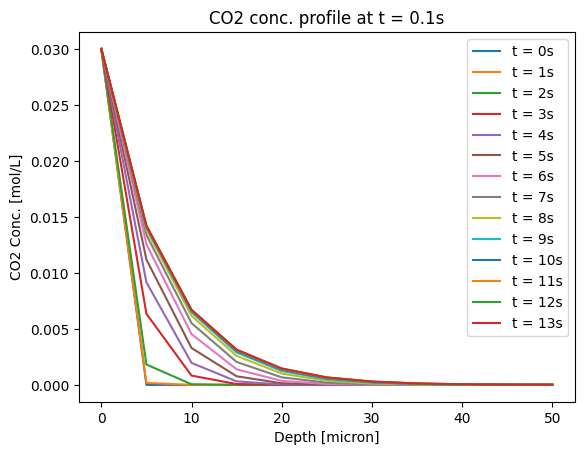

In [51]:

x_vals=np.linspace(0,L,n+2)

#plot conc vs depth as time goes on
for i in range(0,sol.t.size):
	plt.plot(x_vals,conc[:,i], label=f't = {i}s')
	plt.title('CO2 conc. profile at t = '+str(sol.t[i])+'s')
	plt.xlabel('Depth [micron]')
	plt.ylabel('CO2 Conc. [mol/L]')

plt.legend()
plt.show()